# Pelatihan MLP Kalibrasi pada Data Asli

**Tanggal kegiatan: 16 Agustus 2026**

Rancangan MLP kemarin diterapkan ke kode pelatihan, lalu dilatih memakai data
kalibrasi yang sudah terkumpul dari lapangan.

Sekaligus dilakukan pemeriksaan kejujuran: apakah model yang dihasilkan benar-benar
lebih baik daripada tebakan paling sederhana?

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
RANDOM_STATE = 42

df = pd.read_csv("../Firmware/kalibrasi_antaraga-001.csv")
df["gender_code"] = (df.gender.str.upper() == "L").astype(float)

FITUR = ["ir_dc_mean", "ir_ac_p2p", "red_dc_mean", "red_ac_p2p",
         "bpm", "age_years", "gender_code"]
TARGET = {
    "gula_darah_mg_dl": "Gula Darah", "kolesterol_mg_dl": "Kolesterol",
    "asam_urat_mg_dl": "Asam Urat", "sistolik_mmhg": "Sistolik",
    "diastolik_mmhg": "Diastolik",
}
print(f"Data kalibrasi: {len(df)} baris, {df.subject_id.nunique()} subjek unik")
print(f"Fitur: {len(FITUR)}  |  Target: {len(TARGET)}")

Data kalibrasi: 5 baris, 5 subjek unik
Fitur: 7  |  Target: 5


## 1. Dataset yang Terkumpul

In [2]:
kol = ["subject_id","age_years","gender","bpm"] + list(TARGET)
print(df[kol].to_string(index=False))
print()
print("KELENGKAPAN")
for c in FITUR + list(TARGET):
    print(f"  {c:20s}: {df[c].notna().sum()}/{len(df)} terisi")

subject_id  age_years gender   bpm  gula_darah_mg_dl  kolesterol_mg_dl  asam_urat_mg_dl  sistolik_mmhg  diastolik_mmhg
      S001       20.0      L  70.1             119.0             212.0              6.3          125.0            77.0
      S002       57.0      P  93.6             101.0             200.0              4.6          173.0           102.0
      S003       75.0      P  42.9             183.0             232.0              4.5          153.0            94.0
      S004       70.0      P 103.1             153.0             269.0              4.8          157.0            88.0
      S005       76.0      L  63.9              98.0             244.0              5.3          166.0            86.0

KELENGKAPAN
  ir_dc_mean          : 5/5 terisi
  ir_ac_p2p           : 5/5 terisi
  red_dc_mean         : 5/5 terisi
  red_ac_p2p          : 5/5 terisi
  bpm                 : 5/5 terisi
  age_years           : 5/5 terisi
  gender_code         : 5/5 terisi
  gula_darah_mg_dl    : 5/5 

## 2. Pelatihan dengan Kapasitas Menyesuaikan Jumlah Data

Karena baru 5 subjek, aturan penskalaan dari rancangan kemarin memilih jaringan
paling kecil: satu lapisan 4 neuron dengan regularisasi kuat (alpha = 1,0).

In [3]:
n = len(df)
if n < 10:
    kw = dict(hidden_layer_sizes=(4,), alpha=1.0, max_iter=5000)
elif n < 30:
    kw = dict(hidden_layer_sizes=(16, 8), alpha=0.1, max_iter=3000)
else:
    kw = dict(hidden_layer_sizes=(64, 32), alpha=0.01, max_iter=500)
kw.update(activation="relu", solver="lbfgs", random_state=RANDOM_STATE)

print(f"n = {n}  ->  lapisan {kw['hidden_layer_sizes']}, alpha {kw['alpha']}, "
      f"solver {kw['solver']}")
print(f"Validasi silang: LeaveOneOut (tiap subjek hanya punya 1 rekaman)\n")

hasil = {}
X = df[FITUR].values.astype(float)
Xs = StandardScaler().fit_transform(X)

for kolom, label in TARGET.items():
    y = df[kolom].values.astype(float)
    ycv = cross_val_predict(MLPRegressor(**kw), Xs, y, cv=LeaveOneOut())
    # Tolok ukur: tebak rata-rata subjek lain, tanpa memakai sensor sama sekali
    ybase = np.array([np.delete(y, i).mean() for i in range(len(y))])
    hasil[label] = {
        "y": y, "mlp": ycv, "base": ybase,
        "mae_mlp": mean_absolute_error(y, ycv),
        "mae_base": mean_absolute_error(y, ybase),
        "r2_mlp": r2_score(y, ycv),
    }

print(f"{'Parameter':13s}{'MAE MLP':>10}{'MAE tebak rata2':>18}{'R2 MLP':>10}  hasil")
print("-" * 66)
for label, h in hasil.items():
    menang = "MLP lebih baik" if h["mae_mlp"] < h["mae_base"] else "KALAH dari tebakan"
    print(f"{label:13s}{h['mae_mlp']:>10.2f}{h['mae_base']:>18.2f}"
          f"{h['r2_mlp']:>10.3f}  {menang}")

kalah = sum(1 for h in hasil.values() if h["mae_mlp"] >= h["mae_base"])
print()
print(f"MLP kalah dari tebakan rata-rata pada {kalah} dari {len(hasil)} parameter.")

n = 5  ->  lapisan (4,), alpha 1.0, solver lbfgs
Validasi silang: LeaveOneOut (tiap subjek hanya punya 1 rekaman)

Parameter       MAE MLP   MAE tebak rata2    R2 MLP  hasil
------------------------------------------------------------------
Gula Darah        45.09             37.20    -1.565  KALAH dari tebakan
Kolesterol        51.51             25.40    -3.723  KALAH dari tebakan
Asam Urat          0.46              0.70     0.055  MLP lebih baik
Sistolik          22.30             15.80    -1.321  KALAH dari tebakan
Diastolik          6.00              8.60     0.297  MLP lebih baik

MLP kalah dari tebakan rata-rata pada 3 dari 5 parameter.


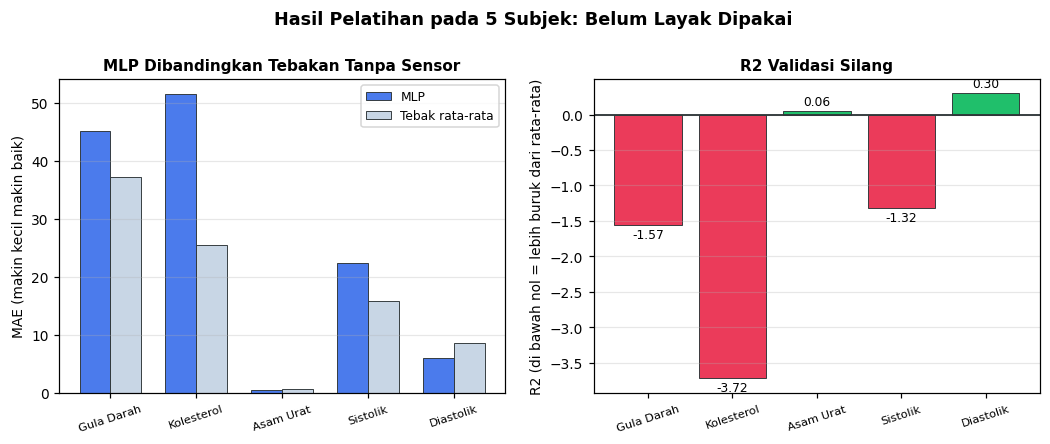

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.7))

lbl = list(hasil)
xp = np.arange(len(lbl)); w = .36
b1 = ax[0].bar(xp - w/2, [hasil[l]["mae_mlp"] for l in lbl], w,
               label="MLP", color="#4b7bec", edgecolor="#2d3436", linewidth=.6)
b2 = ax[0].bar(xp + w/2, [hasil[l]["mae_base"] for l in lbl], w,
               label="Tebak rata-rata", color="#c8d6e5", edgecolor="#2d3436", linewidth=.6)
ax[0].set_xticks(xp, lbl, fontsize=7.5, rotation=18)
ax[0].set_ylabel("MAE (makin kecil makin baik)")
ax[0].set_title("MLP Dibandingkan Tebakan Tanpa Sensor", fontsize=10, fontweight="bold")
ax[0].legend(fontsize=8); ax[0].grid(axis="y", alpha=.3)

r2s = [hasil[l]["r2_mlp"] for l in lbl]
warna = ["#20bf6b" if r > 0 else "#eb3b5a" for r in r2s]
b3 = ax[1].bar(lbl, r2s, color=warna, edgecolor="#2d3436", linewidth=.6)
ax[1].bar_label(b3, fmt="%.2f", fontsize=8, padding=2)
ax[1].axhline(0, color="#2d3436", lw=1.2)
ax[1].set_ylabel("R2 (di bawah nol = lebih buruk dari rata-rata)")
ax[1].set_title("R2 Validasi Silang", fontsize=10, fontweight="bold")
ax[1].tick_params(axis="x", labelsize=7.5, rotation=18)
ax[1].grid(axis="y", alpha=.3)

fig.suptitle("Hasil Pelatihan pada 5 Subjek: Belum Layak Dipakai",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()

## 3. Kesimpulan: Pipeline Berjalan, Modelnya Belum

Kode pelatihan berfungsi: kelima model terbentuk, artefak tersimpan, dan dapat
dipanggil dari dashboard maupun pipeline penerimaan data.

**Tetapi modelnya sendiri belum layak dipakai.** R2 negatif pada mayoritas parameter
berarti model masih kalah dari sekadar menebak nilai rata-rata — tanpa memakai
sensor sama sekali.

Sebabnya jelas dan sudah diperkirakan: **7 fitur dilatih dari 5 baris data**.
Persamaannya lebih sedikit daripada variabel yang dicari.

Ada tiga persoalan komposisi yang juga perlu dibereskan pada pengambilan data
berikutnya:

| Persoalan | Kondisi sekarang | Yang dikejar |
|---|---|---|
| Tidak ada subjek sehat | Kolesterol 5 dari 5 di atas 200 mg/dL | Minimal 10 subjek di bawah 200 |
| Usia berhimpit dengan penyakit | Satu-satunya subjek muda juga satu-satunya yang sehat | Minimal 8 subjek usia di bawah 50 |
| Jumlah subjek | 5 | 30 agar validasi silang 5-fold bermakna |

Persoalan kedua paling berbahaya: bila semua yang tua kebetulan sakit dan semua yang
muda kebetulan sehat, model cukup menebak dari usia dan tetap terlihat akurat —
sensornya tidak berperan sama sekali. Ini sejalan dengan temuan pada model XGBoost,
di mana usia menyumbang 50,2% keputusan.

Angka pada notebook ini **tidak dilaporkan sebagai capaian**, melainkan sebagai
catatan bahwa pengumpulan data harus dilanjutkan.